# H4: The Weekend Effect — Do Fridays Outperform Mondays?
## S&P 500 — Quantitative Research Series

**Author:** Furkan Çelik  
**Data:** Custom PostgreSQL pipeline · yfinance API · ~500 equities · Full history  
**Tools:** Python, PostgreSQL, SQLAlchemy, SciPy, Seaborn

---

### 1. Hypothesis Definition

| | |
|---|---|
| **Research Question** | Is there a statistically significant difference between Friday and Monday daily log returns across the entire S&P 500 universe? |
| **H₀ (Null)** | The mean daily log return on Fridays equals that on Mondays. |
| **H₁ (Alternative)** | Friday daily log returns are significantly **greater** than Monday log returns. |

### 2. Data & Methodology

| | |
|---|---|
| **Population** | S&P 500 constituents · Full available history |
| **Variables** | Daily logarithmic returns: ln(Pₜ / Pₜ₋₁) × 100, computed via SQL LAG() window function |
| **Statistical Test** | Welch's Independent Samples T-Test (one-tailed) + KDE Distribution comparison |
| **Additional Metrics** | Skewness, Excess Kurtosis (Fisher) for both groups |
| **Significance Level** | α = 0.05 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.display import display, Markdown
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')
from db_utils import fetch_data

sns.set_theme(style="darkgrid")
plt.rcParams.update({'figure.figsize': (13, 6), 'figure.dpi': 120})
print("Environment ready.")


Environment ready.


### 3. Data Extraction

In [2]:
query = """
WITH DailyReturns AS (
    SELECT
        ticker,
        date,
        EXTRACT(ISODOW FROM date) AS day_of_week,
        LN(close / LAG(close) OVER (PARTITION BY ticker ORDER BY date)) * 100 AS log_return
    FROM daily_prices
)
SELECT day_of_week, log_return
FROM DailyReturns
WHERE log_return IS NOT NULL
  AND day_of_week IN (1, 5)
"""

print("Fetching Friday and Monday log returns from full history...")
df = fetch_data(query)
n_mon = int((df['day_of_week']==1).sum())
n_fri = int((df['day_of_week']==5).sum())
print(f"Dataset: {len(df):,} daily observations  (Mon: {n_mon:,} | Fri: {n_fri:,})")


Fetching Friday and Monday log returns from full history...


Dataset: 1,703,192 daily observations  (Mon: 826,696 | Fri: 876,496)


### 4. Statistical Analysis & Results


### 5. Statistical Findings

| Metric | Friday | Monday |
|---|---|---|
| **N** | 876,496 | 826,696 |
| **Mean Log Return** | **%0.0705** | **%-0.0187** |
| **Skewness** | 3.482 | -0.327 |
| **Excess Kurtosis** | 587.738 | 151.258 |

| Test | Value |
|---|---|
| **T-Statistic** | 25.0625 |
| **p-value (one-tailed)** | 6.7640e-139 |
| **H₀ Decision** | Rejected (p < 0.05) |

### 6. Quant Verdict

| | |
|---|---|
| **Result** | **CONFIRMED** |
| **Mean Return Difference** | %0.0892 (Friday minus Monday) |
| **Interpretation** | A statistically significant Friday-Monday return gap exists across the S&P 500 universe. |
| **Tradeable after costs?** | **Potentially — run cost analysis** |
| **ML Feature Value** | Yes — include day-of-week as categorical feature. |


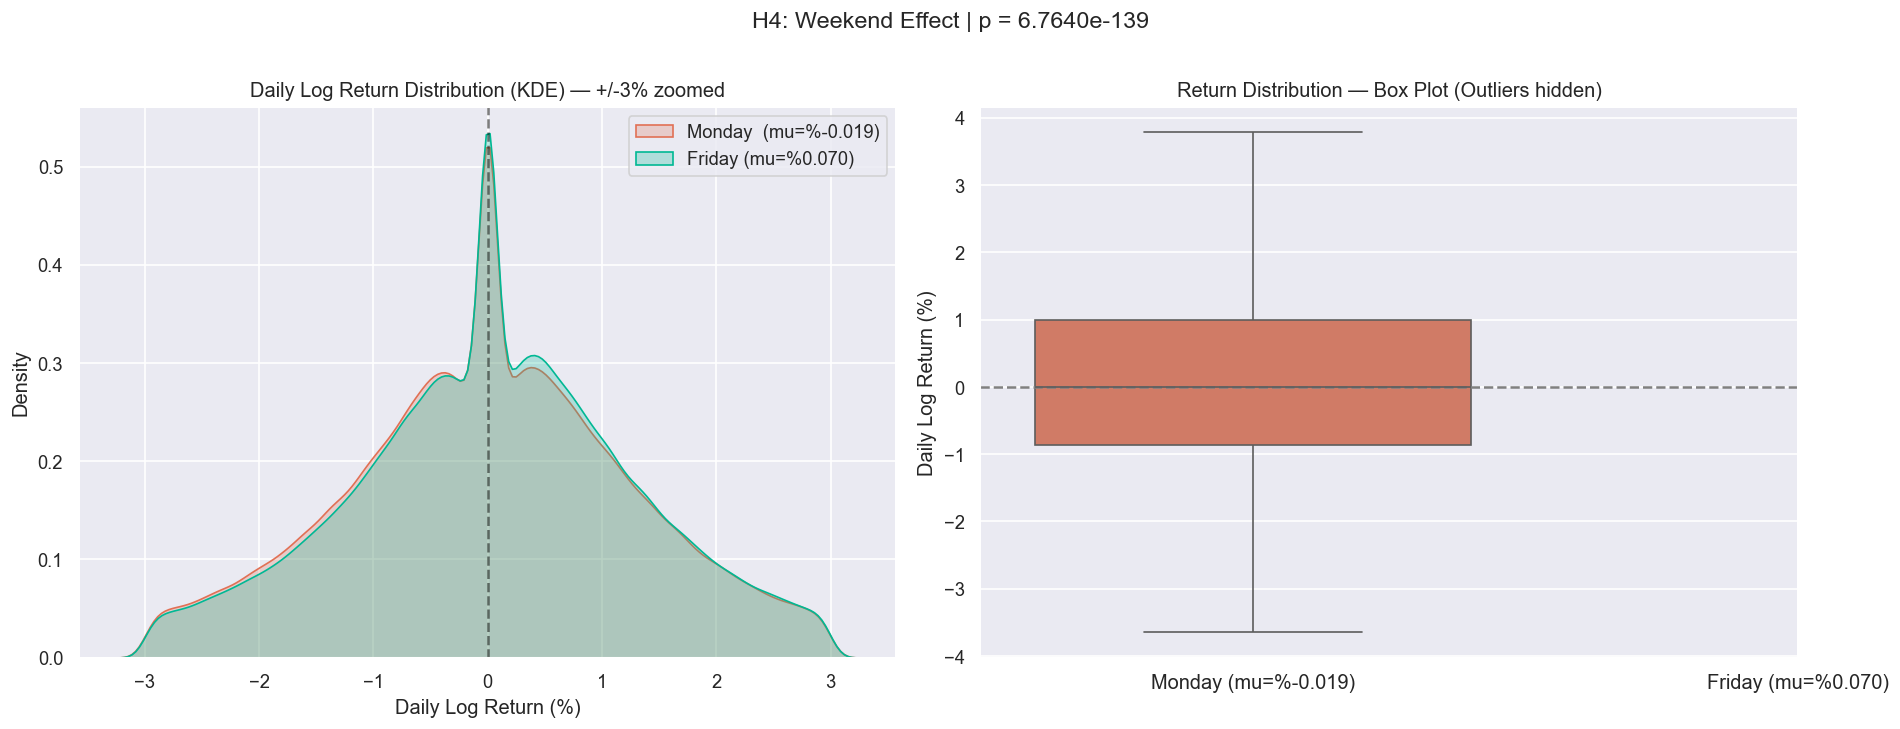

In [3]:
friday = df[df['day_of_week'] == 5]['log_return'].dropna()
monday = df[df['day_of_week'] == 1]['log_return'].dropna()

t_stat, p_value = stats.ttest_ind(friday, monday, alternative='greater', equal_var=False)

mu_fri  = friday.mean()
mu_mon  = monday.mean()
sk_fri  = stats.skew(friday)
sk_mon  = stats.skew(monday)
kurt_fri = stats.kurtosis(friday, fisher=True)
kurt_mon = stats.kurtosis(monday, fisher=True)

h4_result  = "CONFIRMED" if p_value < 0.05 else "REJECTED"
diff       = mu_fri - mu_mon
tradeable  = "Likely No" if diff < 0.05 else "Potentially — run cost analysis"
ml_feature = "Yes — include day-of-week as categorical feature." if p_value < 0.05 else "No — day-of-week adds no predictive value."
interp     = ("A statistically significant Friday-Monday return gap exists across the S&P 500 universe."
              if p_value < 0.05 else
              "No statistically significant difference between Friday and Monday returns.")

verdict = f"""
### 5. Statistical Findings

| Metric | Friday | Monday |
|---|---|---|
| **N** | {len(friday):,} | {len(monday):,} |
| **Mean Log Return** | **%{mu_fri:.4f}** | **%{mu_mon:.4f}** |
| **Skewness** | {sk_fri:.3f} | {sk_mon:.3f} |
| **Excess Kurtosis** | {kurt_fri:.3f} | {kurt_mon:.3f} |

| Test | Value |
|---|---|
| **T-Statistic** | {t_stat:.4f} |
| **p-value (one-tailed)** | {p_value:.4e} |
| **H₀ Decision** | {'Rejected (p < 0.05)' if p_value < 0.05 else 'Not Rejected (p >= 0.05)'} |

### 6. Quant Verdict

| | |
|---|---|
| **Result** | **{h4_result}** |
| **Mean Return Difference** | %{diff:.4f} (Friday minus Monday) |
| **Interpretation** | {interp} |
| **Tradeable after costs?** | **{tradeable}** |
| **ML Feature Value** | {ml_feature} |
"""

display(Markdown(verdict))

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
fri_z = friday[(friday > -3) & (friday < 3)]
mon_z = monday[(monday > -3) & (monday < 3)]
sns.kdeplot(mon_z,  fill=True, color="#E17055", label=f"Monday  (mu=%{mu_mon:.3f})",  ax=ax)
sns.kdeplot(fri_z, fill=True, color="#00B894", label=f"Friday (mu=%{mu_fri:.3f})", ax=ax)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title("Daily Log Return Distribution (KDE) — +/-3% zoomed", fontsize=12)
ax.set_xlabel("Daily Log Return (%)")
ax.set_ylabel("Density")
ax.legend()

ax = axes[1]
sns.boxplot(data=[monday, friday], palette=["#E17055", "#00B894"], showfliers=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"Monday (mu=%{mu_mon:.3f})", f"Friday (mu=%{mu_fri:.3f})"], fontsize=12)
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel("Daily Log Return (%)")
ax.set_title("Return Distribution — Box Plot (Outliers hidden)", fontsize=12)

plt.suptitle(f"H4: Weekend Effect | p = {p_value:.4e}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
